# Book Recommender Project

#### Personalized book suggestions using data, NLP, and Streamlit

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).
* Years: 1975-2024

Books API from [openlibrary](https://openlibrary.org/developers/api). 
* Years: 1900-1975

Developed by: Bryan Calderon

Extracting the 10 most popular books per year!

## **NLP and recomendation system**
#### Applying **TF-IDF vectorization**

* Loading packages and dataset

In [1]:
import requests
import pandas as pd
import time
import re

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pickle
import os
import nltk

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

* Loading data and preparing variables for functions

In [2]:
df_nlp = pd.read_csv("../data/Books_Clusters_PCA.csv")

In [3]:
# Selecting text columns
text_columns = [
    "title",
    "author",
    "genres",
    "description",
    "cluster_label"]

In [4]:
# Creating a conbines text variable
df_nlp["combined_text"] = (
    df_nlp["title"] + " " +
    df_nlp["author"] + " " +
    df_nlp["genres"] + " " +
    df_nlp["description"] + " " +
    df_nlp["cluster_label"])

In [5]:
# Cleaning and preparing text
def clean_text(text):
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [6]:
df_nlp["clean_text"] = df_nlp["combined_text"].apply(clean_text) # returning cleaning text variable

In [7]:
df_nlp["text_length"] = df_nlp["clean_text"].apply(lambda x: len(x.split()))

df_nlp["text_length"].describe()

count    1229.000000
mean      113.804719
std        70.335267
min        20.000000
25%        68.000000
50%        82.000000
75%       149.000000
max       457.000000
Name: text_length, dtype: float64

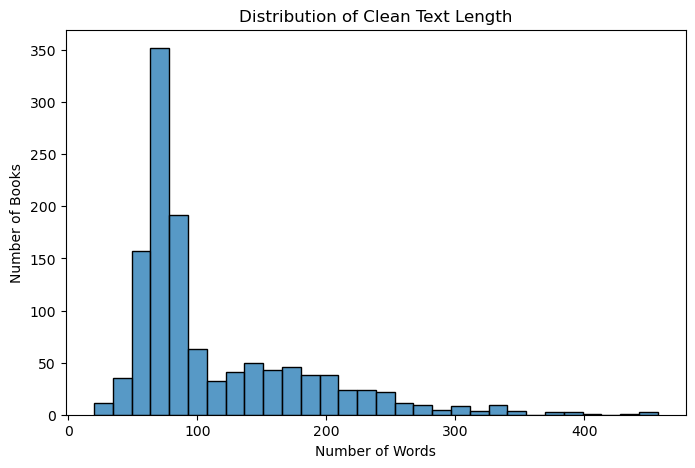

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_nlp["text_length"], bins=30)
plt.title("Distribution of Clean Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Books")
plt.show()

Most books have clean text descriptions between 50 and 100 words, while a smaller number of books contain longer descriptions. This indicates that the dataset has enough textual content for TF-IDF vectorization, although the amount of text varies across books.

## **TF-IDF vectorization**

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop_words = list(ENGLISH_STOP_WORDS.union([
    "book", "books", "story", "stories", "novel", "novels",
    "fiction", "general", "literature", "english",
    "edition", "author", "read", "reader", "readers"]))  # Words that can make aquard the models genres


mod1 = TfidfVectorizer(
    stop_words=custom_stop_words,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85)

In [10]:
mod1_matrix = mod1.fit_transform(df_nlp["clean_text"])
mod1_matrix.shape

(1229, 5000)

In [11]:
feature_names = mod1.get_feature_names_out()
mod1_scores = np.asarray(mod1_matrix.mean(axis=0)).ravel()

df_terms = pd.DataFrame({
    "term": feature_names,
    "score": mod1_scores}).sort_values("score", ascending=False)

df_terms.head(30)

,term,score
3030,mystery,0.029830
3804,science,0.028164
765,children,0.027372
1600,fantasy,0.026947
3672,romance,0.022945
2684,life,0.020331
4979,young,0.019601
2492,juvenile,0.018821
171,american,0.018116
37,adult,0.017406


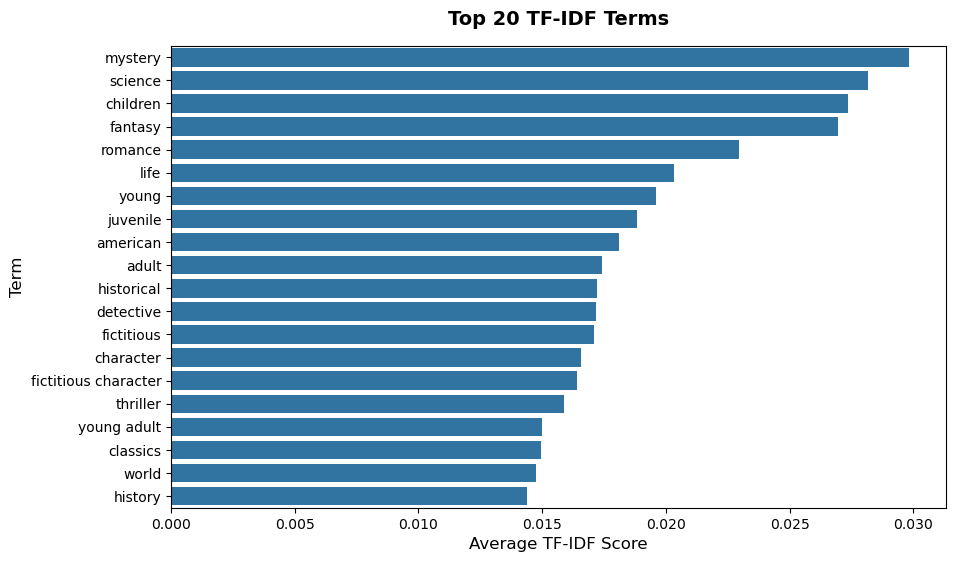

In [12]:
top_terms = df_terms.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms, x="score", y="term")
plt.title("Top 20 TF-IDF Terms", fontsize=14, pad=15, weight="bold")
plt.xlabel("Average TF-IDF Score", fontsize=12)
plt.ylabel("Term", fontsize=12)
plt.show()

In [ ]:
cosine_sim = cosine_similarity(mod1_matrix)
cosine_sim.shape

(1229, 1229)

### **Recommendation function**

In [14]:
def recommend_books(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = sorted(
        similarity_scores, 
        key=lambda x: x[1], 
        reverse=True)
    
    # Skip the first book because it is the same book
    similarity_scores = similarity_scores[1:n+1]
    
    book_indices = [i[0] for i in similarity_scores]
    scores = [i[1] for i in similarity_scores]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"]].copy()
    
    recommendations["similarity_score"] = scores
    
    return recommendations

In [15]:
df_nlp["title"].sample(10, random_state=42)

548     The Stars My Destination
1125             Big Little Lies
244               Tod in Venedig
552              Giovanni's Room
1163                      Verity
1048         Water for Elephants
809                         Cujo
589                 Deathworld 1
101       The Emerald City of Oz
128                    El Dorado
Name: title, dtype: object

* Testing the recomendation function

In [16]:
recommend_books("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.206160
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198397
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198287
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.187248
824,A Is for Alibi,Sue Grafton,1982,3.86,193648,"Mystery, Fiction, Crime, Mystery Thriller, Aud...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.180044


In [17]:
recommend_books(df_nlp["title"].iloc[0], df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score
262,The Case-Book of Sherlock Holmes,Arthur Conan Doyle,1927,4.548387,31,"Fiction, English Detective and mystery stories...",General Fiction,Open Library API,0.553095
129,The Poison Belt,Arthur Conan Doyle,1913,4.500000,4,"Professor Challenger (Fictitious character), F...",General Fiction,Open Library API,0.308182
161,His Last Bow [8 stories],Arthur Conan Doyle,1917,4.133333,30,"short stories, Detective and mystery fiction, ...",General Fiction,Open Library API,0.260216
6,The Lost World,Arthur Conan Doyle,1900,4.045454,44,"Adventure stories, Atlantis, Dinosaurs, Discov...",General Fiction,Open Library API,0.259685
134,The Valley of Fear,Arthur Conan Doyle,1914,4.148148,27,"English Detective and mystery stories, Fiction...",General Fiction,Open Library API,0.233905


#### Improved version considering clustering

In [18]:
def recommend_books_same_cluster(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    book_cluster = df.loc[idx, "cluster"]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    
    # Remove same book
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx ]
    
    # Add cluster preference
    adjusted_scores = []
    
    for i, score in similarity_scores:
        same_cluster_bonus = 0.10 if df.loc[i, "cluster"] == book_cluster else 0
        adjusted_score = score + same_cluster_bonus
        adjusted_scores.append((i, adjusted_score, score))
    
    adjusted_scores = sorted(
        adjusted_scores, 
        key=lambda x: x[1], 
        reverse=True)
    
    top_books = adjusted_scores[:n]
    
    book_indices = [i[0] for i in top_books]
    final_scores = [i[1] for i in top_books]
    original_scores = [i[2] for i in top_books]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"]].copy()
    
    recommendations["similarity_score"] = original_scores
    recommendations["final_score"] = final_scores
    
    return recommendations

In [19]:
recommend_books_same_cluster("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score,final_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.206160,0.306160
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198397,0.298397
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198287,0.298287
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.187248,0.287248
824,A Is for Alibi,Sue Grafton,1982,3.86,193648,"Mystery, Fiction, Crime, Mystery Thriller, Aud...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.180044,0.280044


#### Improved version considering clustering and weight score

In [20]:
def recommend_books_weighted(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx ]
    
    recommendations = []
    
    for i, similarity in similarity_scores:
        rating_scaled = df.loc[i, "average_rating"] / 5
        popularity_scaled = np.log1p(df.loc[i, "ratings_count"]) / np.log1p(df["ratings_count"].max())
        
        final_score = (
            0.70 * similarity +
            0.20 * rating_scaled +
            0.10 * popularity_scaled )
        
        recommendations.append((i, similarity, final_score))
    
    recommendations = sorted(
        recommendations,
        key=lambda x: x[2],
        reverse=True)
    
    top_books = recommendations[:n]
    
    book_indices = [i[0] for i in top_books]
    
    results = df.iloc[book_indices][[
        "title",
        "author",
        "source_year",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "source"]].copy()
    
    results["similarity_score"] = [i[1] for i in top_books]
    results["final_score"] = [i[2] for i in top_books]
    
    return results

In [21]:
recommend_books_weighted("The Silent Patient", df_nlp, cosine_sim, n=5)

,title,author,source_year,average_rating,ratings_count,genres,cluster_label,source,similarity_score,final_score
1125,Big Little Lies,Liane Moriarty,2014,4.31,1135117,"Fiction, Mystery, Book Club, Contemporary, Thr...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.206160,0.402407
1203,The Housemaid,Freida McFadden,2022,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.187248,0.394962
870,Misery,Stephen King,1987,4.22,840913,"Horror, Fiction, Thriller, Mystery, Audiobook,...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198287,0.391452
1138,Pretty Girls,Karin Slaughter,2015,4.00,762622,"Thriller, Mystery, Mystery Thriller, Fiction, ...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.198397,0.382128
1170,A Good Girl's Guide to Murder,Holly Jackson,2019,4.28,1857089,"Mystery, Thriller, Young Adult, Mystery Thrill...","Mystery, Thriller & Horror",Goodreads Popular by Year,0.167190,0.376954


The NLP model powers the recommendation system. It compares books based on their title, author, genre, description, and cluster label. Using TF-IDF and cosine similarity, the system finds books with similar textual content. I also added rating and popularity weights to recommend books that are not only similar, but also well-rated and relevant.

### VADER

This is just an attempt, however it does not have any sence to implement this type of model. Probably requieres the implementation of reviews to make it more interesting the analysis or at least more accuarate!

THIS IS JUST FOR PRACTICE

In [22]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [23]:
df_sentiment = df_nlp.copy()

In [24]:
def get_vader_scores(text):
    if pd.isna(text):
        text = ""
    
    scores = analyzer.polarity_scores(str(text))
    
    return pd.Series({
        "sentiment_neg": scores["neg"],
        "sentiment_neu": scores["neu"],
        "sentiment_pos": scores["pos"],
        "sentiment_compound": scores["compound"] })

In [33]:
analyzer = SentimentIntensityAnalyzer()

In [34]:
sentiment_scores = df_sentiment["description"].apply(get_vader_scores)

df_sentiment = pd.concat(
    [df_sentiment, sentiment_scores],
    axis=1)

In [35]:
def sentiment_label(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [36]:
df_sentiment["description_sentiment"] = df_sentiment["sentiment_compound"].apply(sentiment_label)

In [37]:
df_sentiment[[
    "title",
    "description",
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_pos",
    "sentiment_compound",
    "description_sentiment"]].head()

,title,description,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound,description_sentiment
0,The Hound of the Baskervilles,The Hound of the Baskervilles Arthur Conan Doy...,0.131,0.829,0.041,-0.7269,Negative
1,The Classic Tale of the Velveteen Rabbit,The Classic Tale of the Velveteen Rabbit Marge...,0.000,0.931,0.069,0.4404,Positive
2,No country for old men,No country for old men Cormac McCarthy Fiction...,0.053,0.894,0.053,0.0000,Neutral
3,The Prophet,"The Prophet Kahlil Gibran Poetry, Classics, Li...",0.000,1.000,0.000,0.0000,Neutral
4,The Railway Children,The Railway Children Edith Nesbit Brothers and...,0.078,0.862,0.060,0.0258,Neutral


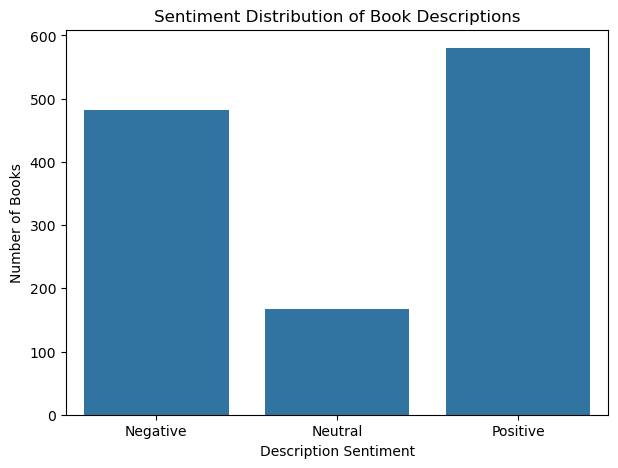

In [38]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_sentiment,
    x="description_sentiment",
    order=["Negative", "Neutral", "Positive"])

plt.title("Sentiment Distribution of Book Descriptions")
plt.xlabel("Description Sentiment")
plt.ylabel("Number of Books")
plt.show()

In [39]:
sentiment_by_cluster = (
    df_sentiment
    .groupby(["cluster_label", "description_sentiment"])
    .size()
    .reset_index(name="book_count"))

sentiment_by_cluster

,cluster_label,description_sentiment,book_count
0,Children’s & juvenile fantasy,Negative,50
1,Children’s & juvenile fantasy,Neutral,48
2,Children’s & juvenile fantasy,Positive,102
3,General genre fiction,Negative,251
4,General genre fiction,Neutral,107
5,General genre fiction,Positive,187
6,Historical & classic fiction,Negative,28
7,Historical & classic fiction,Neutral,4
8,Historical & classic fiction,Positive,87
9,Nonfiction & history,Negative,16


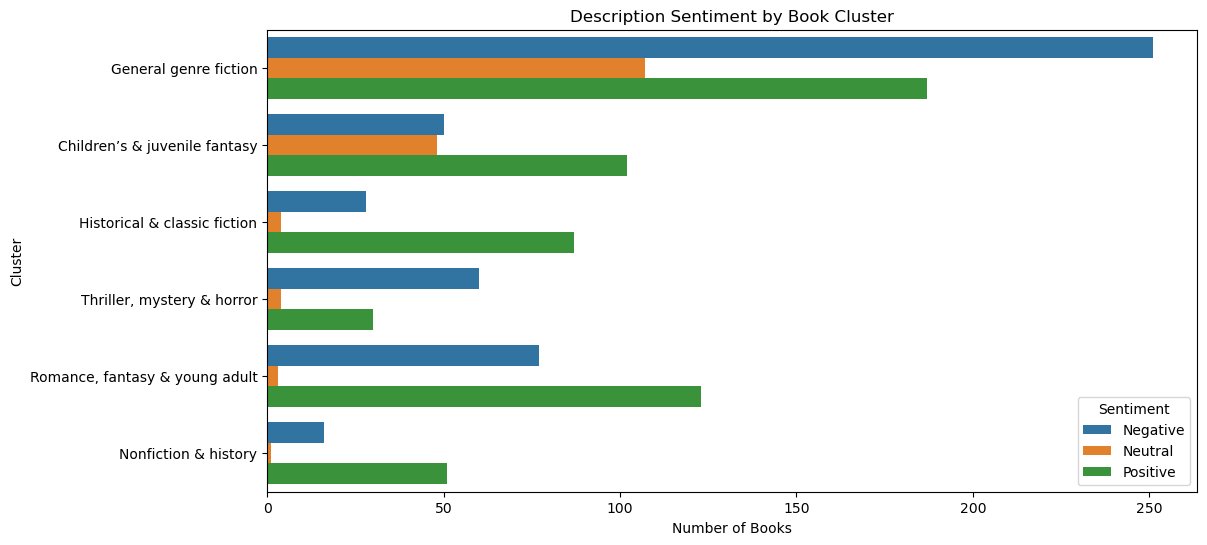

In [40]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_sentiment,
    y="cluster_label",
    hue="description_sentiment",
    hue_order=["Negative", "Neutral", "Positive"])

plt.title("Description Sentiment by Book Cluster")
plt.xlabel("Number of Books")
plt.ylabel("Cluster")
plt.legend(title="Sentiment")
plt.show()

In [41]:
df_sentiment["combined_text"] = (
    df_sentiment["title"].fillna("") + " " +
    df_sentiment["author"].fillna("") + " " +
    df_sentiment["genres"].fillna("") + " " +
    df_sentiment["description"].fillna("") + " " +
    df_sentiment["cluster_label"].fillna("") + " " +
    df_sentiment["description_sentiment"].fillna("")
)

In [42]:
def recommend_books_with_sentiment(title, df, cosine_sim, n=5):
    title = title.lower()
    
    matches = df[df["title"].str.lower().str.contains(title, na=False)]
    
    if matches.empty:
        return "Book not found. Try another title."
    
    idx = matches.index[0]
    
    input_sentiment = df.loc[idx, "description_sentiment"]
    
    similarity_scores = list(enumerate(cosine_sim[idx]))
    similarity_scores = [
        (i, score) for i, score in similarity_scores if i != idx
    ]
    
    adjusted_scores = []
    
    for i, score in similarity_scores:
        sentiment_bonus = 0.05 if df.loc[i, "description_sentiment"] == input_sentiment else 0
        final_score = score + sentiment_bonus
        adjusted_scores.append((i, score, final_score))
    
    adjusted_scores = sorted(
        adjusted_scores,
        key=lambda x: x[2],
        reverse=True
    )
    
    top_books = adjusted_scores[:n]
    book_indices = [i[0] for i in top_books]
    
    recommendations = df.iloc[book_indices][[
        "title",
        "author",
        "average_rating",
        "ratings_count",
        "genres",
        "cluster_label",
        "description_sentiment"
    ]].copy()
    
    recommendations["similarity_score"] = [i[1] for i in top_books]
    recommendations["final_score"] = [i[2] for i in top_books]
    
    return recommendations

In [43]:
recommend_books_with_sentiment("The Silent Patient", df_sentiment, cosine_sim, n=5)

,title,author,average_rating,ratings_count,genres,cluster_label,description_sentiment,similarity_score,final_score
1203,The Housemaid,Freida McFadden,4.27,3779611,"Thriller, Mystery, Fiction, Audiobook, Book Cl...","Thriller, mystery & horror",Positive,0.186776,0.236776
894,Jurassic Park,Michael Crichton,4.14,1081696,"Science Fiction, Fiction, Thriller, Horror, Fa...","Thriller, mystery & horror",Positive,0.167266,0.217266
1114,The Husband's Secret,Liane Moriarty,3.94,734612,"Fiction, Book Club, Mystery, Contemporary, Chi...","Thriller, mystery & horror",Positive,0.166581,0.216581
1224,The Housemaid is Watching,Freida McFadden,3.85,1131225,"Thriller, Mystery, Audiobook, Fiction, Mystery...","Thriller, mystery & horror",Positive,0.162947,0.212947
1130,The Girl on the Train,Paula Hawkins,3.96,3345878,"Fiction, Mystery, Thriller, Book Club, Mystery...","Thriller, mystery & horror",Positive,0.162181,0.212181
